In [2]:
!pip install ucimlrepo


Размер датасета: 303 наблюдений, 13 признаков

Первые 5 строк данных:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

Целевая переменная:
   num
0    0
1    2
2    1
3    0
4    0

Информация о типах данных:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
d

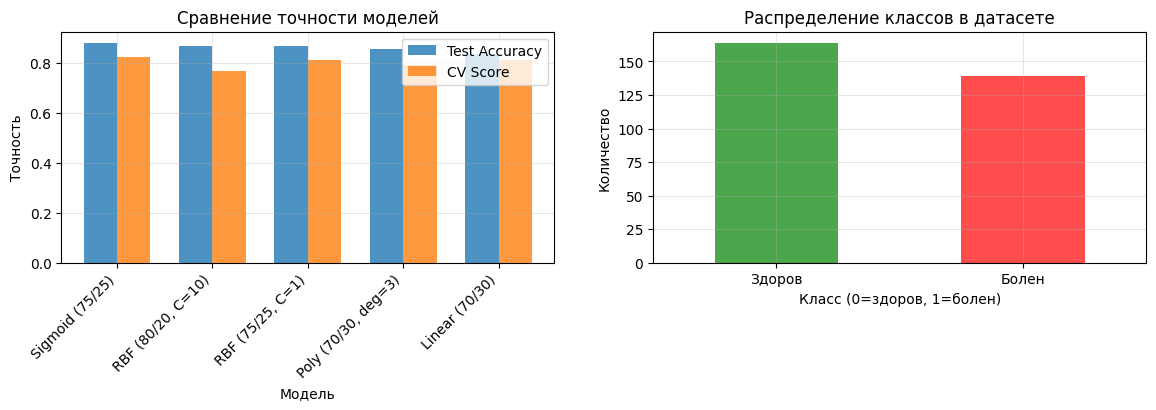

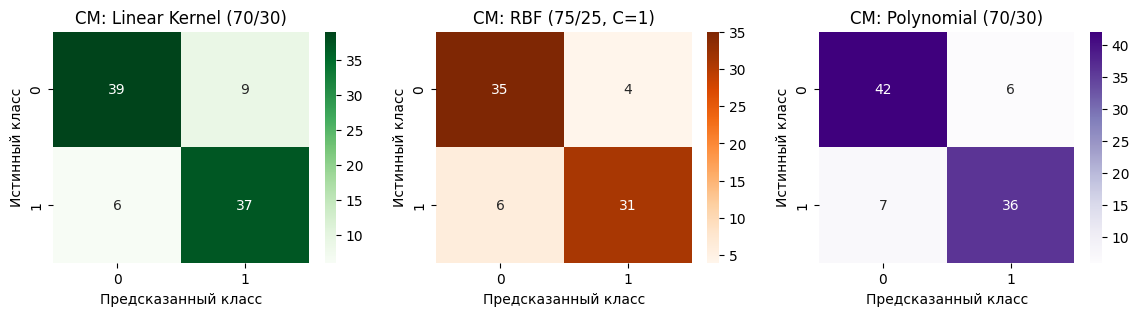

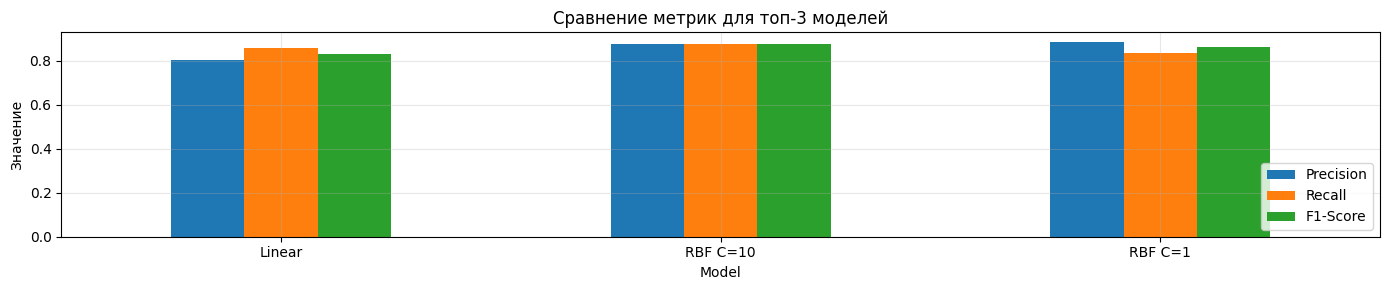

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

print(f"\nРазмер датасета: {X.shape[0]} наблюдений, {X.shape[1]} признаков")
print(f"\nПервые 5 строк данных:")
print(X.head())
print(f"\nЦелевая переменная:")
print(y.head())

print("\nИнформация о типах данных:")
print(X.dtypes)

print("\nСтатистическое описание данных:")
print(X.describe())

print(f"\nПропущенные значения:\n{X.isnull().sum()}")
X = X.fillna(X.median())

y_binary = (y > 0).astype(int)
print(f"\nРаспределение целевой переменной:")
print(y_binary['num'].value_counts())

print("\nНезависимые переменные (13 признаков):", list(X.columns))
print("Зависимая переменная: num (наличие сердечного заболевания)")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


results = []

print("МОДЕЛЬ 1: Linear Kernel, разбиение 70/30")

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_scaled, y_binary, test_size=0.3, random_state=42
)
print(f"Обучающая выборка: {len(X_train1)} наблюдений")
print(f"Тестовая выборка: {len(X_test1)} наблюдений")

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train1, y_train1.values.ravel())

y_pred1 = svm_linear.predict(X_test1)

acc1 = accuracy_score(y_test1, y_pred1)
cv_scores1 = cross_val_score(svm_linear, X_train1, y_train1.values.ravel(), cv=5)

print(f"\nТочность на тестовой выборке: {acc1:.4f}")
print(f"Перекрестная проверка (5-fold CV): {cv_scores1.mean():.4f} (+/- {cv_scores1.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test1, y_pred1))

results.append({
    'model': 'Linear (70/30)',
    'kernel': 'linear',
    'C': 1.0,
    'split': '70/30',
    'test_acc': acc1,
    'cv_mean': cv_scores1.mean(),
    'cv_std': cv_scores1.std()
})

print("МОДЕЛЬ 2: RBF Kernel, разбиение 80/20, C=10, gamma=0.1")

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42
)
print(f"Обучающая выборка: {len(X_train2)} наблюдений")
print(f"Тестовая выборка: {len(X_test2)} наблюдений")

svm_rbf = SVC(kernel='rbf', C=10.0, gamma=0.1, random_state=42)
svm_rbf.fit(X_train2, y_train2.values.ravel())

y_pred2 = svm_rbf.predict(X_test2)
acc2 = accuracy_score(y_test2, y_pred2)
cv_scores2 = cross_val_score(svm_rbf, X_train2, y_train2.values.ravel(), cv=5)

print(f"\nТочность на тестовой выборке: {acc2:.4f}")
print(f"Перекрестная проверка (5-fold CV): {cv_scores2.mean():.4f} (+/- {cv_scores2.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test2, y_pred2))

results.append({
    'model': 'RBF (80/20, C=10)',
    'kernel': 'rbf',
    'C': 10.0,
    'split': '80/20',
    'test_acc': acc2,
    'cv_mean': cv_scores2.mean(),
    'cv_std': cv_scores2.std()
})

print("МОДЕЛЬ 3: RBF Kernel, разбиение 75/25, C=1, gamma='scale'")

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_scaled, y_binary, test_size=0.25, random_state=42
)
print(f"Обучающая выборка: {len(X_train3)} наблюдений")
print(f"Тестовая выборка: {len(X_test3)} наблюдений")

svm_rbf2 = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf2.fit(X_train3, y_train3.values.ravel())

y_pred3 = svm_rbf2.predict(X_test3)
acc3 = accuracy_score(y_test3, y_pred3)
cv_scores3 = cross_val_score(svm_rbf2, X_train3, y_train3.values.ravel(), cv=5)

print(f"\nТочность на тестовой выборке: {acc3:.4f}")
print(f"Перекрестная проверка (5-fold CV): {cv_scores3.mean():.4f} (+/- {cv_scores3.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test3, y_pred3))

results.append({
    'model': 'RBF (75/25, C=1)',
    'kernel': 'rbf',
    'C': 1.0,
    'split': '75/25',
    'test_acc': acc3,
    'cv_mean': cv_scores3.mean(),
    'cv_std': cv_scores3.std()
})

print("МОДЕЛЬ 4: Polynomial Kernel, разбиение 70/30, degree=3")

svm_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42)
svm_poly.fit(X_train1, y_train1.values.ravel())

y_pred4 = svm_poly.predict(X_test1)
acc4 = accuracy_score(y_test1, y_pred4)
cv_scores4 = cross_val_score(svm_poly, X_train1, y_train1.values.ravel(), cv=5)

print(f"\nТочность на тестовой выборке: {acc4:.4f}")
print(f"Перекрестная проверка (5-fold CV): {cv_scores4.mean():.4f} (+/- {cv_scores4.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test1, y_pred4))

results.append({
    'model': 'Poly (70/30, deg=3)',
    'kernel': 'poly',
    'C': 1.0,
    'split': '70/30',
    'test_acc': acc4,
    'cv_mean': cv_scores4.mean(),
    'cv_std': cv_scores4.std()
})


print("МОДЕЛЬ 5: Sigmoid Kernel, разбиение 75/25")

svm_sigmoid = SVC(kernel='sigmoid', C=1.0, random_state=42)
svm_sigmoid.fit(X_train3, y_train3.values.ravel())

y_pred5 = svm_sigmoid.predict(X_test3)
acc5 = accuracy_score(y_test3, y_pred5)
cv_scores5 = cross_val_score(svm_sigmoid, X_train3, y_train3.values.ravel(), cv=5)

print(f"\nТочность на тестовой выборке: {acc5:.4f}")
print(f"Перекрестная проверка (5-fold CV): {cv_scores5.mean():.4f} (+/- {cv_scores5.std():.4f})")
print("\nОтчет классификации:")
print(classification_report(y_test3, y_pred5))

results.append({
    'model': 'Sigmoid (75/25)',
    'kernel': 'sigmoid',
    'C': 1.0,
    'split': '75/25',
    'test_acc': acc5,
    'cv_mean': cv_scores5.mean(),
    'cv_std': cv_scores5.std()
})

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_acc', ascending=False)
print("\n", results_df.to_string(index=False))

print("ТРИ ЛУЧШИЕ МОДЕЛИ:")
top3 = results_df.head(3)
for idx, row in top3.iterrows():
    print(f"\n{row['model']}:")
    print(f"  - Kernel: {row['kernel']}")
    print(f"  - Test Accuracy: {row['test_acc']:.4f}")
    print(f"  - CV Score: {row['cv_mean']:.4f} ± {row['cv_std']:.4f}")

print("СОЗДАНИЕ ГРАФИКОВ")

# График 1: Сравнение точности моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# 1.1 Сравнение точности
ax = axes[0]
models = results_df['model']
test_scores = results_df['test_acc']
cv_scores = results_df['cv_mean']

x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, test_scores, width, label='Test Accuracy', alpha=0.8)
ax.bar(x + width/2, cv_scores, width, label='CV Score', alpha=0.8)
ax.set_xlabel('Модель')
ax.set_ylabel('Точность')
ax.set_title('Сравнение точности моделей')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# 1.2 Распределение целевой переменной
ax = axes[1]
y_binary['num'].value_counts().plot(kind='bar', ax=ax, color=['green', 'red'], alpha=0.7)
ax.set_title('Распределение классов в датасете')
ax.set_xlabel('Класс (0=здоров, 1=болен)')
ax.set_ylabel('Количество')
ax.set_xticklabels(['Здоров', 'Болен'], rotation=0)
ax.grid(True, alpha=0.3)

# График 2: Детальный анализ лучших моделей
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 3))

# 2.1 Confusion Matrix - Модель 1 (Linear)
ax = axes2[0]
cm1 = confusion_matrix(y_test1, y_pred1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_title('CM: Linear Kernel (70/30)')
ax.set_ylabel('Истинный класс')
ax.set_xlabel('Предсказанный класс')

# 2.2 Confusion Matrix - Модель 3
ax = axes2[1]
cm3 = confusion_matrix(y_test3, y_pred3)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', ax=ax)
ax.set_title('CM: RBF (75/25, C=1)')
ax.set_ylabel('Истинный класс')
ax.set_xlabel('Предсказанный класс')

# 2.3 Confusion Matrix - Модель 4 (Poly)
ax = axes2[2]
cm4 = confusion_matrix(y_test1, y_pred4)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Purples', ax=ax)
ax.set_title('CM: Polynomial (70/30)')
ax.set_ylabel('Истинный класс')
ax.set_xlabel('Предсказанный класс')

# График 3: Сравнение метрик precision/recall/f1
fig3, axes3 = plt.subplots(1, 1, figsize=(14, 3))

ax = axes3
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_data = []
for i, (X_test, y_test, y_pred, model_name) in enumerate([
    (X_test1, y_test1, y_pred1, 'Linear'),
    (X_test2, y_test2, y_pred2, 'RBF C=10'),
    (X_test3, y_test3, y_pred3, 'RBF C=1')
]):
    metrics_data.append({
        'Model': model_name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df.set_index('Model').plot(kind='bar', ax=ax, rot=0)
ax.set_title('Сравнение метрик для топ-3 моделей')
ax.set_ylabel('Значение')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()